# Reglas de asociación: el algoritmo a priori

**Unidad 9 · Machine Learning · Notebook 5 de 6**

Cierra la unidad y el bloque no supervisado. Es la rama que el diagrama clásico de `9.0` no
muestra.

## Otra pregunta, otra unidad de análisis

En `9.4` agrupamos **casos parecidos**: países que se parecen entre sí en nueve variables. Acá
la pregunta gira 90 grados:

> **¿Qué atributos aparecen juntos más de lo esperable por azar?**

Ya no agrupamos filas sino que buscamos regularidades entre **columnas**. Y el formato del dato
cambia: en lugar de una matriz de variables continuas, un conjunto de **transacciones**, cada
una un conjunto de ítems presentes.

El método nació en el análisis de canastas de supermercado —de ahí el nombre *market basket
analysis*— para responder qué productos se compran juntos. El ejemplo canónico, tan citado como
dudoso, es que los pañales y la cerveza se venden juntos los viernes.

En ciencia política la estructura del problema aparece cada vez que hay **unidades que exhiben
conjuntos de atributos**: legisladores y sus votos, países y los tratados que firman, electores
y sus posiciones, partidos y sus promesas de campaña.

### En qué se diferencia de lo que ya vimos

De la **correlación**: la correlación resume una relación entre **dos** variables en un número
promedio para toda la muestra. Una regla de asociación identifica **combinaciones específicas de
varios ítems** y puede detectar un patrón que vale para un subconjunto de casos y no para el
resto. Dos variables pueden tener correlación cercana a cero y existir una regla fuerte entre
un valor particular de una y un valor particular de la otra.

De la **clasificación**: no hay una variable objetivo fijada de antemano. El método produce
reglas hacia **todos** los ítems a la vez, y uno decide después qué consecuente le interesa. Es
exploratorio por diseño.

Y una advertencia que conviene dejar establecida antes de empezar: **"asociación" no es
"causa"**. Una regla dice que dos cosas ocurren juntas más de lo esperable. No dice que una
produzca la otra, ni descarta que las dos dependan de una tercera. En nuestro caso la tercera
variable va a ser evidente —la pertenencia a un bloque— y parte del trabajo será mostrar
exactamente eso.

## Requisitos

In [1]:
# Requisitos de este notebook.
# Si te falta alguno, instalalo EN TU PROPIO ENTORNO desde una terminal
# (o descomentando la linea de abajo) y reinicia el kernel:
#
#     pip install numpy pandas matplotlib seaborn scikit-learn statsmodels mlxtend networkx
#
# %pip install numpy pandas matplotlib seaborn scikit-learn statsmodels mlxtend networkx

import importlib

_requeridos = ['numpy', 'pandas', 'matplotlib', 'seaborn', 'sklearn', 'statsmodels', 'mlxtend', 'networkx']
_faltan = []
for _m in _requeridos:
    try:
        _mod = importlib.import_module(_m)
        print(f"  {_m:16s} {getattr(_mod, '__version__', 'sin version')}")
    except ImportError:
        _faltan.append(_m)
        print(f"  {_m:16s} FALTA")

if _faltan:
    print(f"\nFaltan {len(_faltan)} paquetes: {', '.join(_faltan)}.")
    print("Instalalos en tu entorno antes de seguir.")
else:
    print("\nTodo listo.")

  numpy            1.26.4
  pandas           2.2.2
  matplotlib       3.9.2


  seaborn          0.13.2
  sklearn          1.9.0
  statsmodels      0.14.2
  mlxtend          0.23.4


  networkx         3.3

Todo listo.


## Librerías

In [2]:
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import seaborn as sns

from mlxtend.frequent_patterns import apriori, association_rules

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)

SEMILLA = 2025
PALETA = ["#0073C2", "#EFC000", "#CD534C", "#868686", "#1E2749"]

## Las métricas, calculadas a mano

Una **regla de asociación** se escribe

$$ A \Rightarrow B $$

donde $A$ (el *antecedente*) y $B$ (el *consecuente*) son conjuntos de ítems disjuntos. Se lee
"cuando aparece $A$, tiende a aparecer $B$".

Antes de usar ninguna librería, construyamos un ejemplo mínimo y calculemos todo con las manos.
Diez legisladores y tres proyectos.

In [3]:
ejemplo = pd.DataFrame({
    "ley_A": [1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
    "ley_B": [1, 1, 1, 1, 0, 0, 1, 0, 0, 0],
    "ley_C": [1, 1, 0, 0, 1, 1, 1, 1, 1, 0],
}, index=[f"dip_{i+1}" for i in range(10)])
ejemplo

,ley_A,ley_B,ley_C
dip_1,1,1,1
dip_2,1,1,1
dip_3,1,1,0
dip_4,1,1,0
dip_5,1,0,1
dip_6,1,0,1
dip_7,0,1,1
dip_8,0,0,1
dip_9,0,0,1
dip_10,0,0,0


### Soporte

La proporción de transacciones que contienen un conjunto de ítems:

$$ \text{sop}(A) = \frac{\#\{\text{transacciones que contienen } A\}}{N} $$

Mide **cuán frecuente** es el patrón. Un soporte alto significa que la regla habla de muchos
casos; un soporte bajo, que describe un nicho. Es la métrica que el algoritmo usa para podar.

In [4]:
N = len(ejemplo)

def soporte(*items):
    return (ejemplo[list(items)].all(axis=1)).sum() / N

print(f"N = {N} transacciones\n")
for it in ["ley_A", "ley_B", "ley_C"]:
    print(f"  sop({it})            = {ejemplo[it].sum()}/{N} = {soporte(it):.2f}")
print()
for a, b in combinations(["ley_A", "ley_B", "ley_C"], 2):
    print(f"  sop({a}, {b}) = {int(soporte(a, b) * N)}/{N} = {soporte(a, b):.2f}")
print(f"\n  sop(A, B, C)          = {int(soporte('ley_A','ley_B','ley_C') * N)}/{N} "
      f"= {soporte('ley_A', 'ley_B', 'ley_C'):.2f}")

N = 10 transacciones

  sop(ley_A)            = 6/10 = 0.60
  sop(ley_B)            = 5/10 = 0.50
  sop(ley_C)            = 7/10 = 0.70

  sop(ley_A, ley_B) = 4/10 = 0.40
  sop(ley_A, ley_C) = 4/10 = 0.40
  sop(ley_B, ley_C) = 3/10 = 0.30

  sop(A, B, C)          = 2/10 = 0.20


### Confianza

La probabilidad condicional de $B$ dado $A$:

$$ \text{conf}(A \Rightarrow B) = \frac{\text{sop}(A \cup B)}{\text{sop}(A)} = \hat{P}(B \mid A) $$

Mide **cuán confiable** es la implicación. Es la métrica más intuitiva y **la más engañosa**, por
un motivo que vemos enseguida.

Notar que la confianza **no es simétrica**: $\text{conf}(A \Rightarrow B)$ y
$\text{conf}(B \Rightarrow A)$ son distintas.

In [5]:
def confianza(ant, con):
    return soporte(*ant, *con) / soporte(*ant)

print(f"conf(A => B) = sop(A,B)/sop(A) = {soporte('ley_A','ley_B'):.2f}/{soporte('ley_A'):.2f} "
      f"= {confianza(['ley_A'], ['ley_B']):.3f}")
print(f"conf(B => A) = sop(A,B)/sop(B) = {soporte('ley_A','ley_B'):.2f}/{soporte('ley_B'):.2f} "
      f"= {confianza(['ley_B'], ['ley_A']):.3f}")
print("\nLa misma co-ocurrencia, dos confianzas distintas: la métrica no es simétrica.")
print()
print(f"conf(A => C) = {confianza(['ley_A'], ['ley_C']):.3f}")
print(f"conf(B => C) = {confianza(['ley_B'], ['ley_C']):.3f}")

conf(A => B) = sop(A,B)/sop(A) = 0.40/0.60 = 0.667
conf(B => A) = sop(A,B)/sop(B) = 0.40/0.50 = 0.800

La misma co-ocurrencia, dos confianzas distintas: la métrica no es simétrica.

conf(A => C) = 0.667
conf(B => C) = 0.600


### Lift: la métrica que hace el trabajo

Acá está el problema de la confianza. En el ejemplo, $\text{conf}(A \Rightarrow C) = 0.667$:
suena bien. Pero el soporte de C es **0.70**, o sea que el 70% de todos los legisladores votan C
de todas formas. Entre los que votan A, la proporción que vota C es **más baja** que en el
total.

Una confianza alta puede reflejar simplemente que el consecuente es frecuente, no que exista
asociación. El **lift** corrige exactamente eso:

$$ \text{lift}(A \Rightarrow B) = \frac{\text{conf}(A \Rightarrow B)}{\text{sop}(B)}
   = \frac{\text{sop}(A \cup B)}{\text{sop}(A)\,\text{sop}(B)}
   = \frac{\hat{P}(A \cap B)}{\hat{P}(A)\,\hat{P}(B)} $$

Compara la co-ocurrencia observada con la que se esperaría **si los ítems fueran
independientes**:

- $\text{lift} = 1$ → independencia, no hay asociación.
- $\text{lift} > 1$ → aparecen juntos más de lo esperable.
- $\text{lift} < 1$ → aparecen juntos menos de lo esperable (asociación **negativa**).

A diferencia de la confianza, el lift **sí es simétrico**.

In [6]:
def lift(ant, con):
    return confianza(ant, con) / soporte(*con)

print("regla            soporte  confianza    sop(cons)   lift   lectura")
print("-" * 78)
for ant, con in [(["ley_A"], ["ley_B"]), (["ley_B"], ["ley_A"]),
                 (["ley_A"], ["ley_C"]), (["ley_C"], ["ley_A"]),
                 (["ley_B"], ["ley_C"]),
                 (["ley_A", "ley_B"], ["ley_C"])]:
    a = "+".join(x.replace("ley_", "") for x in ant)
    c = "+".join(x.replace("ley_", "") for x in con)
    l = lift(ant, con)
    lectura = "asociación positiva" if l > 1.05 else ("asociación NEGATIVA" if l < 0.95
                                                     else "independientes")
    print(f"{a:>4s} => {c:<4s}      {soporte(*ant, *con):.2f}      {confianza(ant, con):.3f}"
          f"        {soporte(*con):.2f}    {l:.2f}   {lectura}")

regla            soporte  confianza    sop(cons)   lift   lectura
------------------------------------------------------------------------------
   A => B         0.40      0.667        0.50    1.33   asociación positiva
   B => A         0.40      0.800        0.60    1.33   asociación positiva
   A => C         0.40      0.667        0.70    0.95   independientes
   C => A         0.40      0.571        0.60    0.95   independientes
   B => C         0.30      0.600        0.70    0.86   asociación NEGATIVA
 A+B => C         0.20      0.500        0.70    0.71   asociación NEGATIVA


La tabla muestra el punto central del notebook.

**`A ⇒ C` tiene confianza 0.667 y lift 0.95.** Si uno mira solo la confianza, parece una regla
razonable: dos de cada tres legisladores que votan A también votan C. Mirando el lift, la regla
es **inútil o incluso engañosa**: 0.95 significa que votar A hace ligeramente **menos** probable
votar C que en la población general.

**`A ⇒ B` tiene confianza 0.667 y lift 1.67.** Exactamente la misma confianza, y acá sí hay
asociación real, porque B es un ítem poco frecuente.

**Regla operativa: filtrar por soporte y confianza para acotar el problema, ordenar y
seleccionar por lift.** Un informe que reporte reglas ordenadas por confianza está reportando,
sobre todo, qué ítems son frecuentes.

### Dos métricas más

**Leverage** (o *piatetsky-shapiro*): la diferencia —en lugar del cociente— entre lo observado
y lo esperado bajo independencia.

$$ \text{leverage}(A \Rightarrow B) = \text{sop}(A \cup B) - \text{sop}(A)\,\text{sop}(B) $$

Va de $-0.25$ a $0.25$. Su ventaja sobre el lift: **pondera por frecuencia**. Un lift de 5 sobre
un soporte de 0.001 describe seis casos; el leverage lo penaliza y el lift no. Cuando hay que
elegir reglas que sirvan para actuar sobre mucha gente, leverage ordena mejor.

**Conviction**: cuántas veces más frecuentemente la regla se equivocaría si $A$ y $B$ fueran
independientes.

$$ \text{conviction}(A \Rightarrow B) = \frac{1 - \text{sop}(B)}{1 - \text{conf}(A \Rightarrow B)} $$

Vale 1 bajo independencia y tiende a infinito cuando la confianza tiende a 1. Es útil porque, a
diferencia del lift, **es sensible a la dirección** de la regla.

In [7]:
def leverage(ant, con):
    return soporte(*ant, *con) - soporte(*ant) * soporte(*con)

def conviction(ant, con):
    c = confianza(ant, con)
    return np.inf if c >= 1 else (1 - soporte(*con)) / (1 - c)

filas = []
for ant, con in [(["ley_A"], ["ley_B"]), (["ley_B"], ["ley_A"]),
                 (["ley_A"], ["ley_C"]), (["ley_B"], ["ley_C"]),
                 (["ley_A", "ley_B"], ["ley_C"])]:
    filas.append({
        "regla": "+".join(x.replace("ley_", "") for x in ant) + " => "
                 + "+".join(x.replace("ley_", "") for x in con),
        "soporte": round(soporte(*ant, *con), 3),
        "confianza": round(confianza(ant, con), 3),
        "lift": round(lift(ant, con), 3),
        "leverage": round(leverage(ant, con), 3),
        "conviction": round(conviction(ant, con), 3),
    })
pd.DataFrame(filas)

,regla,soporte,confianza,lift,leverage,conviction
0,A => B,0.4,0.667,1.333,0.10,1.50
1,B => A,0.4,0.800,1.333,0.10,2.00
2,A => C,0.4,0.667,0.952,-0.02,0.90
3,B => C,0.3,0.600,0.857,-0.05,0.75
4,A+B => C,0.2,0.500,0.714,-0.08,0.60


## El algoritmo a priori

Con $p$ ítems hay $2^p - 1$ conjuntos posibles. Con nuestros 15 proyectos y dos posiciones cada
uno son 30 ítems, o sea más de **mil millones** de conjuntos candidatos. Enumerarlos todos es
imposible, y ahí está el aporte del algoritmo.

### La propiedad de clausura descendente

> **Si un conjunto de ítems es infrecuente, ninguno de sus superconjuntos puede ser frecuente.**

La demostración es de una línea: agregar un ítem a un conjunto solo puede **reducir** la
cantidad de transacciones que lo contienen, porque impone una condición adicional. Entonces
$\text{sop}(A \cup \{x\}) \leq \text{sop}(A)$ siempre.

La consecuencia es enorme: si `{contra_ley_bases, favor_privatizaciones}` no alcanza el soporte
mínimo, **no hace falta evaluar ninguno** de los conjuntos que lo contienen. Se poda una rama
entera del retículo de un solo golpe.

El algoritmo recorre por niveles:

1. Contar el soporte de todos los conjuntos de tamaño 1. Descartar los infrecuentes.
2. Generar candidatos de tamaño 2 **solo combinando los frecuentes de tamaño 1**.
3. Contar, descartar, y repetir con tamaño 3, 4, …
4. Detenerse cuando no queden candidatos frecuentes.

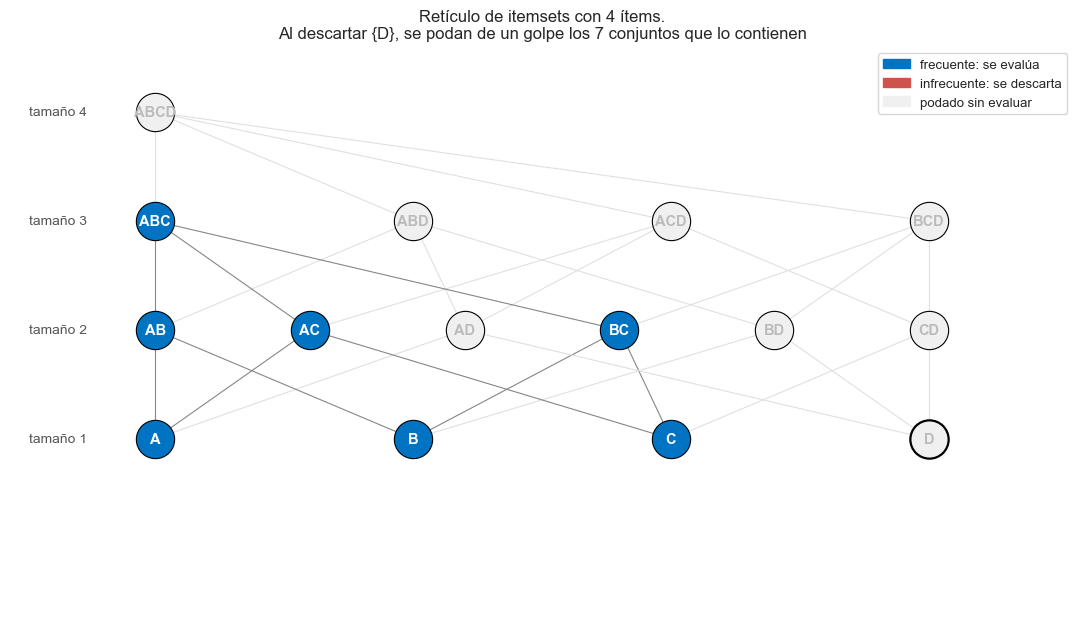

conjuntos totales con 4 ítems: 15
conjuntos que contienen a D  : 8 -> se podan sin contar su soporte


In [8]:
# El retículo de itemsets y qué poda la clausura descendente
fig, ax = plt.subplots(figsize=(11, 6.4))
ax.set_xlim(-0.5, 10.5); ax.set_ylim(-0.6, 4.6); ax.axis("off")

ITEMS = ["A", "B", "C", "D"]
INFRECUENTES = {"D"}          # supongamos que D no alcanza el soporte mínimo

niveles = {k: [c for c in combinations(ITEMS, k)] for k in range(1, 5)}
posiciones = {}
for k, conjuntos in niveles.items():
    xs = np.linspace(1, 9, len(conjuntos))
    for x, c in zip(xs, conjuntos):
        posiciones[c] = (x, k)

def podado(c):
    return bool(set(c) & INFRECUENTES)

for c, (x, y) in posiciones.items():
    for otro, (x2, y2) in posiciones.items():
        if len(otro) == len(c) + 1 and set(c) <= set(otro):
            gris = podado(c) or podado(otro)
            ax.plot([x, x2], [y, y2], color="#e0e0e0" if gris else PALETA[3],
                    lw=0.8, zorder=1)

for c, (x, y) in posiciones.items():
    esta_podado = podado(c)
    color = "#f0f0f0" if esta_podado else (PALETA[2] if set(c) == INFRECUENTES else PALETA[0])
    ax.scatter([x], [y], s=760, color=color, edgecolor="black",
               linewidth=1.6 if set(c) == INFRECUENTES else 0.8, zorder=3)
    ax.text(x, y, "".join(c), ha="center", va="center", fontsize=10.5,
            color="#bbb" if esta_podado else "white", fontweight="bold", zorder=4)

ax.text(-0.3, 1, "tamaño 1", fontsize=10, va="center", color="#555")
ax.text(-0.3, 2, "tamaño 2", fontsize=10, va="center", color="#555")
ax.text(-0.3, 3, "tamaño 3", fontsize=10, va="center", color="#555")
ax.text(-0.3, 4, "tamaño 4", fontsize=10, va="center", color="#555")

ax.legend(handles=[
    mpatches.Patch(color=PALETA[0], label="frecuente: se evalúa"),
    mpatches.Patch(color=PALETA[2], label="infrecuente: se descarta"),
    mpatches.Patch(color="#f0f0f0", label="podado sin evaluar"),
], loc="upper right", fontsize=9.5)
ax.set_title("Retículo de itemsets con 4 ítems.\n"
             "Al descartar {D}, se podan de un golpe los 7 conjuntos que lo contienen",
             fontsize=12)
plt.tight_layout()
plt.show()

print(f"conjuntos totales con 4 ítems: {2**4 - 1}")
print(f"conjuntos que contienen a D  : {2**3} -> se podan sin contar su soporte")

## Los datos: votaciones nominales en la Cámara de Diputados

El problema que vamos a resolver:

> **¿Qué proyectos de ley se votan juntos, quiénes son los legisladores pivote y se puede
> anticipar el voto de un diputado en un proyecto nuevo?**

Las votaciones nominales (*roll-call votes*) son uno de los datos más usados en el estudio de
legislaturas: registran, para cada proyecto, cómo votó cada legislador. Su estructura es
naturalmente transaccional —cada legislador es una transacción, cada posición un ítem— así que
el método se aplica sin forzar nada.

### Los datos son simulados, y así se construyen

Usamos una **simulación** con estructura realista de la Cámara de Diputados argentina. Es
importante ser explícito sobre eso: los diputados no existen, los resultados no corresponden a
ninguna votación real, y **ninguna conclusión sustantiva de este notebook dice nada sobre la
política argentina**. Lo que es real es el método y la estructura del problema.

El generador tiene supuestos declarados:

1. **Siete bloques** con las bancas aproximadas de la composición reciente de la Cámara (257 en
   total).
2. Cada bloque tiene una posición en **dos dimensiones latentes**: económica
   (mercado ↔ Estado) y federal (nación ↔ provincias). Que dos dimensiones basten es un supuesto
   fuerte, y es el que la literatura de *spatial voting* suele usar.
3. Cada bloque tiene un parámetro de **disciplina**: cuánto se desvían sus diputados de la
   posición del bloque. Le asignamos alta disciplina a los bloques ideológicamente compactos y
   baja a las coaliciones heterogéneas.
4. Cada proyecto tiene **cargas** en las dos dimensiones y un **corrimiento** que fija su nivel
   general de apoyo, para que no todos se aprueben ni todos se rechacen.
5. La probabilidad de votar a favor sale de una función logística de la utilidad —el producto
   entre la posición del diputado y las cargas del proyecto—, que es el mismo modelo de `9.2`
   usado en dirección generativa.
6. Un **6% de ausencias** aleatorias, que es lo que hace que la matriz transaccional tenga
   huecos como en un dato real.

In [9]:
rng = np.random.default_rng(SEMILLA)

BLOQUES = {
    #                          bancas   eco   fed  disciplina
    "Unión por la Patria":       (99, -1.5,  0.3, 0.92),
    "La Libertad Avanza":        (38,  1.9, -0.9, 0.90),
    "PRO":                       (37,  1.3, -0.4, 0.80),
    "UCR":                       (34,  0.4,  0.6, 0.62),
    "Coalición Federal":         (23,  0.1,  1.2, 0.55),
    "Izquierda":                  (5, -2.0,  0.0, 0.97),
    "Provinciales":              (21, -0.2,  1.8, 0.50),
}

PROYECTOS = [
    # (nombre, carga económica, carga federal, corrimiento)
    ("ley_bases",             1.7, -0.5, -0.2),
    ("reforma_laboral",       1.6, -0.3, -0.5),
    ("presupuesto",           1.2, -0.6,  0.1),
    ("privatizaciones",       1.8, -0.4, -0.7),
    ("retenciones_agro",      1.1,  0.7,  0.0),
    ("coparticipacion",      -0.2,  1.9,  0.3),
    ("obra_publica_prov",    -0.5,  1.7,  0.4),
    ("emergencia_jubilados", -1.6,  0.2,  0.2),
    ("financiamiento_univ",  -1.5,  0.3,  0.6),
    ("salud_emergencia",     -1.4,  0.4,  0.5),
    ("boleta_unica",          0.5, -0.3,  0.9),
    ("ficha_limpia",          0.7, -0.2,  0.7),
    ("reforma_politica",      0.3,  0.4,  0.1),
    ("dnu_delegadas",         1.5, -1.1, -0.4),
    ("tarifas_energia",       1.4, -0.5, -0.6),
]

P_AUSENCIA = 0.06

# --- diputados: posición del bloque + desvío individual según la disciplina
diputados = []
identificador = 0
for bloque, (bancas, eco, fed, disciplina) in BLOQUES.items():
    dispersion = (1 - disciplina) * 2.2
    for _ in range(bancas):
        diputados.append({"diputado": f"D{identificador:03d}", "bloque": bloque,
                          "pos_eco": eco + rng.normal(0, dispersion),
                          "pos_fed": fed + rng.normal(0, dispersion)})
        identificador += 1
diputados = pd.DataFrame(diputados)

# --- votaciones
registros = []
for d in diputados.itertuples():
    for nombre, w_eco, w_fed, corrimiento in PROYECTOS:
        if rng.random() < P_AUSENCIA:
            voto = "ausente"
        else:
            utilidad = 1.35 * (d.pos_eco * w_eco + d.pos_fed * w_fed) + 2.0 * corrimiento
            voto = "favor" if rng.random() < 1 / (1 + np.exp(-utilidad)) else "contra"
        registros.append({"diputado": d.diputado, "bloque": d.bloque,
                          "proyecto": nombre, "voto": voto})

votaciones = pd.DataFrame(registros)
print(f"diputados: {len(diputados)}   proyectos: {len(PROYECTOS)}   "
      f"registros: {len(votaciones)}")
votaciones.head(8)

diputados: 257   proyectos: 15   registros: 3855


,diputado,bloque,proyecto,voto
0,D000,Unión por la Patria,ley_bases,ausente
1,D000,Unión por la Patria,reforma_laboral,contra
2,D000,Unión por la Patria,presupuesto,contra
3,D000,Unión por la Patria,privatizaciones,contra
4,D000,Unión por la Patria,retenciones_agro,contra
5,D000,Unión por la Patria,coparticipacion,contra
6,D000,Unión por la Patria,obra_publica_prov,favor
7,D000,Unión por la Patria,emergencia_jubilados,favor


In [10]:
# Guardamos el resultado como artefacto reproducible
destino = Path("../../dataset/votaciones_sim")
destino.mkdir(parents=True, exist_ok=True)
archivo = destino / "votaciones_hcdn_sim.csv"
votaciones.to_csv(archivo, index=False, encoding="utf-8")
print(f"guardado en {archivo}  ({archivo.stat().st_size / 1024:.0f} KB)")
print("\nCon la semilla fija, el archivo es idéntico en cualquier máquina.")

guardado en ..\..\dataset\votaciones_sim\votaciones_hcdn_sim.csv  (163 KB)

Con la semilla fija, el archivo es idéntico en cualquier máquina.


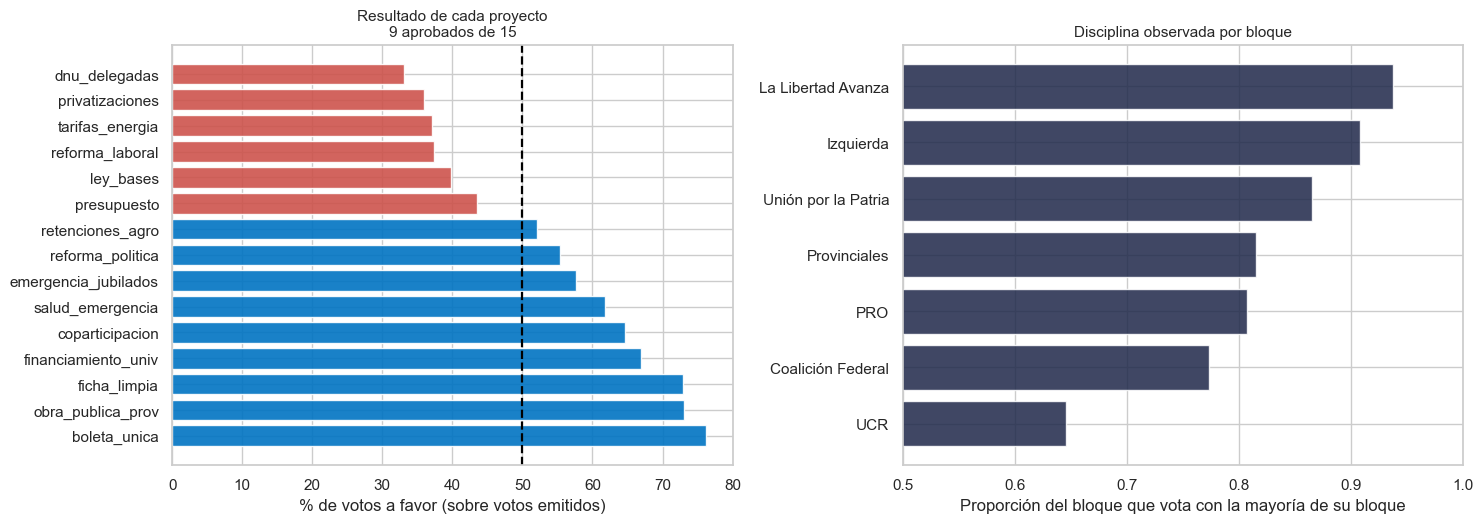

In [11]:
emitidos = votaciones[votaciones["voto"] != "ausente"]

resultado = (emitidos.groupby("proyecto")["voto"]
             .apply(lambda s: (s == "favor").mean())
             .sort_values(ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.4))

colores = [PALETA[0] if v > 0.5 else PALETA[2] for v in resultado]
axes[0].barh(resultado.index, resultado.values * 100, color=colores, alpha=0.9)
axes[0].axvline(50, color="black", ls="--", lw=1.6)
axes[0].set_xlabel("% de votos a favor (sobre votos emitidos)")
axes[0].set_title(f"Resultado de cada proyecto\n"
                  f"{int((resultado > 0.5).sum())} aprobados de {len(resultado)}", fontsize=11)

disciplina_obs = (emitidos.groupby(["bloque", "proyecto"])["voto"]
                  .apply(lambda s: s.value_counts(normalize=True).iloc[0])
                  .groupby("bloque").mean().sort_values())
axes[1].barh(disciplina_obs.index, disciplina_obs.values, color=PALETA[4], alpha=0.85)
axes[1].set_xlim(0.5, 1.0)
axes[1].set_xlabel("Proporción del bloque que vota con la mayoría de su bloque")
axes[1].set_title("Disciplina observada por bloque", fontsize=11)

plt.tight_layout()
plt.show()

La simulación se comporta como se esperaba: nueve proyectos aprobados y seis rechazados, con
resultados que van del 33% al 76% de apoyo, y una disciplina que va de 0.94 en La Libertad
Avanza a **0.65 en la UCR**, el bloque que definimos como más heterogéneo.

Retener ese dato: la UCR es el bloque menos cohesionado, y eso va a reaparecer en el análisis.

## De la matriz de votos al formato transaccional

`apriori` necesita una matriz booleana de **transacciones × ítems**. Cada fila es un diputado y
cada columna un ítem presente o ausente.

La decisión de diseño importante es **qué es un ítem**. La opción ingenua sería un ítem por
proyecto, presente si el diputado votó a favor. Pero eso perdería la mitad de la información:
votar en contra de un proyecto es una posición tan informativa como votar a favor, y las
coaliciones se construyen tanto sobre apoyos compartidos como sobre rechazos compartidos.

Entonces generamos **dos ítems por proyecto**: `favor_X` y `contra_X`. Los dos son mutuamente
exclusivos y las ausencias no generan ítem —simplemente ese diputado no tiene ninguno de los dos
para ese proyecto—, que es la forma natural de representar un dato faltante en formato
transaccional.

In [12]:
emitidos = emitidos.assign(item=emitidos["voto"] + "_" + emitidos["proyecto"])

canasta = (emitidos.assign(presente=True)
           .pivot_table(index="diputado", columns="item", values="presente",
                        fill_value=False)
           .astype(bool))

print(f"matriz transaccional: {canasta.shape[0]} diputados × {canasta.shape[1]} ítems")
print(f"ítems por diputado: media {canasta.sum(axis=1).mean():.1f} "
      f"(sobre {len(PROYECTOS)} proyectos posibles)")
canasta.iloc[:6, :6]

matriz transaccional: 257 diputados × 30 ítems
ítems por diputado: media 14.1 (sobre 15 proyectos posibles)


item,contra_boleta_unica,contra_coparticipacion,contra_dnu_delegadas,contra_emergencia_jubilados,contra_ficha_limpia,contra_financiamiento_univ
diputado,,,,,,
D000,True,True,True,False,False,False
D001,False,False,False,False,True,False
D002,True,False,True,False,True,False
D003,False,False,True,False,False,False
D004,False,False,True,False,True,False
D005,False,False,True,False,True,False


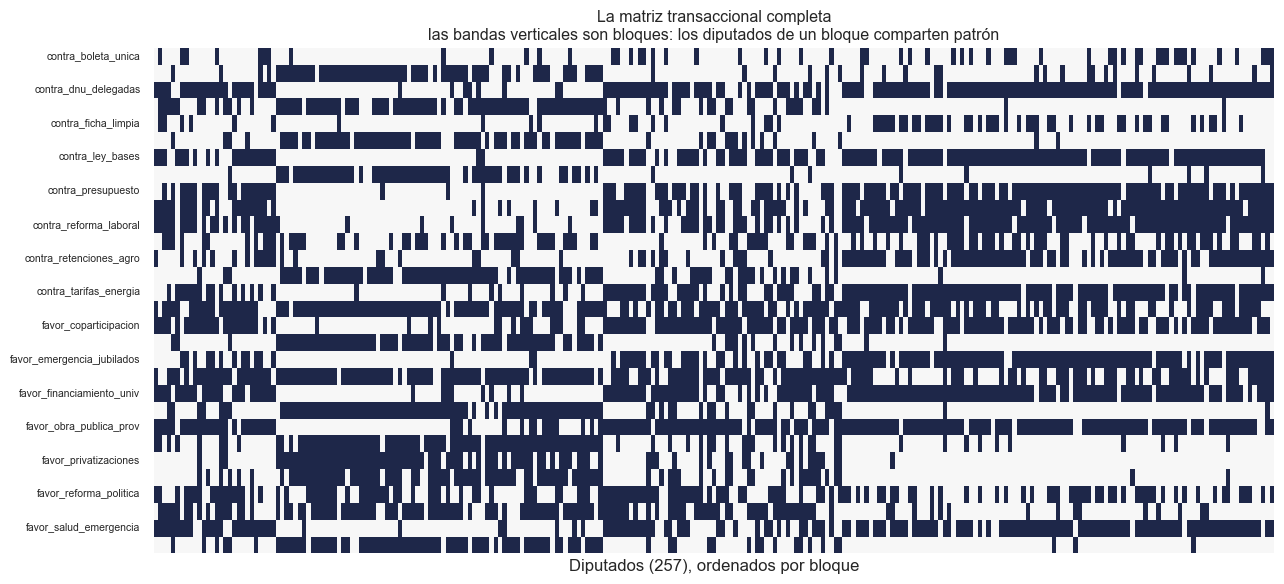

In [13]:
fig, ax = plt.subplots(figsize=(13, 6))
orden_dip = (votaciones.pivot_table(index="diputado", columns="bloque",
                                    values="voto", aggfunc="size")
             .notna().idxmax(axis=1).sort_values().index)
sns.heatmap(canasta.loc[orden_dip].T, cmap=["#f7f7f7", PALETA[4]], cbar=False, ax=ax)
ax.set_xlabel(f"Diputados ({len(canasta)}), ordenados por bloque")
ax.set_ylabel("")
ax.set_xticks([])
ax.tick_params(axis="y", labelsize=7.5)
ax.set_title("La matriz transaccional completa\n"
             "las bandas verticales son bloques: los diputados de un bloque comparten patrón",
             fontsize=11.5)
plt.tight_layout()
plt.show()

La estructura es visible a ojo: los diputados de un mismo bloque forman **bandas verticales** con
patrones casi idénticos. Eso es lo que el algoritmo va a encontrar, y también la razón por la que
hay que tener cuidado al interpretar: las reglas van a estar reflejando, en buena medida, la
pertenencia a bloques.

## Itemsets frecuentes y la explosión combinatoria

Antes de fijar un umbral, vale ver por qué el umbral importa tanto.

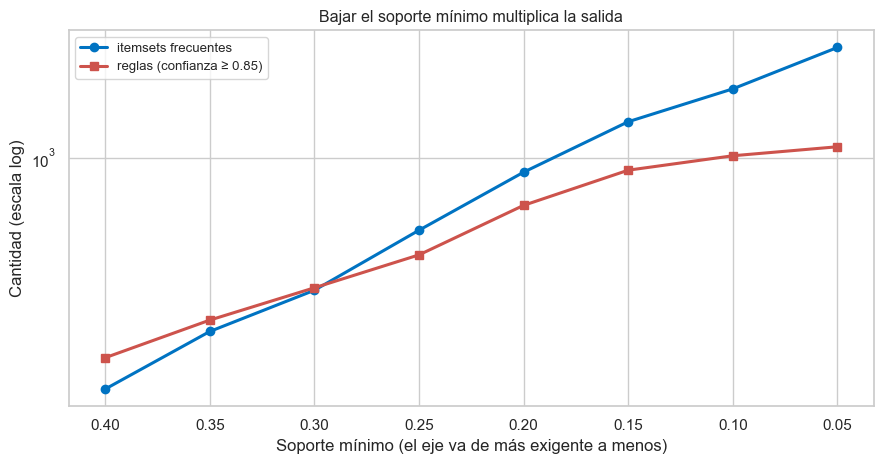

,soporte_minimo,itemsets_frecuentes,reglas_conf_0.85
0,0.40,168,214
1,0.35,262,286
2,0.30,360,367
3,0.25,572,473
4,0.20,895,693
5,0.15,1321,909
6,0.10,1702,1016
7,0.05,2342,1089


In [14]:
exploracion = []
for min_sop in [0.40, 0.35, 0.30, 0.25, 0.20, 0.15, 0.10, 0.05]:
    frecuentes = apriori(canasta, min_support=min_sop, use_colnames=True, max_len=3)
    reglas_tmp = association_rules(frecuentes, num_itemsets=len(canasta),
                                   metric="confidence", min_threshold=0.85)
    reglas_tmp = reglas_tmp[reglas_tmp["consequents"].apply(len) == 1]
    exploracion.append({"soporte_minimo": min_sop,
                        "itemsets_frecuentes": len(frecuentes),
                        "reglas_conf_0.85": len(reglas_tmp)})

tabla_exp = pd.DataFrame(exploracion)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(tabla_exp["soporte_minimo"], tabla_exp["itemsets_frecuentes"], "o-",
        lw=2.2, color=PALETA[0], label="itemsets frecuentes")
ax.plot(tabla_exp["soporte_minimo"], tabla_exp["reglas_conf_0.85"], "s-",
        lw=2.2, color=PALETA[2], label="reglas (confianza ≥ 0.85)")
ax.invert_xaxis()
ax.set_yscale("log")
ax.set_xlabel("Soporte mínimo (el eje va de más exigente a menos)")
ax.set_ylabel("Cantidad (escala log)")
ax.set_title("Bajar el soporte mínimo multiplica la salida", fontsize=11.5)
ax.legend(fontsize=9.5)
plt.tight_layout()
plt.show()

tabla_exp

Bajar el soporte de 0.40 a 0.05 multiplica los itemsets por más de veinte. Y no es solo un
problema de cómputo: **una salida de treinta mil reglas es tan inútil como ninguna**, porque no
se puede revisar.

Además, cuando se generan decenas de miles de reglas sobre los mismos datos, algunas van a
parecer fuertes por azar. Es el problema de las comparaciones múltiples, y en reglas de
asociación no hay una corrección estándar. La defensa práctica es doble: **umbrales exigentes**
y **validar sustantivamente** las reglas que se reportan.

Elegimos soporte mínimo **0.25** —la regla tiene que valer para al menos un cuarto de la
Cámara—, confianza mínima **0.85**, longitud máxima 3 y consecuente único, que es lo que hace
las reglas legibles.

In [15]:
MIN_SOPORTE, MIN_CONFIANZA = 0.25, 0.85

frecuentes = apriori(canasta, min_support=MIN_SOPORTE, use_colnames=True, max_len=3)
frecuentes["tamaño"] = frecuentes["itemsets"].apply(len)
print(f"itemsets frecuentes: {len(frecuentes)}")
print(frecuentes["tamaño"].value_counts().sort_index().rename("cantidad").to_frame().T.to_string())

reglas = association_rules(frecuentes, num_itemsets=len(canasta),
                           metric="confidence", min_threshold=MIN_CONFIANZA)
reglas = reglas[reglas["consequents"].apply(len) == 1].copy()
reglas["n_antecedentes"] = reglas["antecedents"].apply(len)
reglas["antecedente"] = reglas["antecedents"].apply(lambda s: " + ".join(sorted(s)))
reglas["consecuente"] = reglas["consequents"].apply(lambda s: list(s)[0])

print(f"\nreglas con consecuente único: {len(reglas)}")
print(f"rango de lift: {reglas['lift'].min():.2f} a {reglas['lift'].max():.2f}")

itemsets frecuentes: 572
tamaño     1    2    3
cantidad  29  163  380

reglas con consecuente único: 473
rango de lift: 1.20 a 2.46


In [16]:
COLUMNAS = ["antecedente", "consecuente", "support", "confidence", "lift",
            "leverage", "conviction"]
print("Las 12 reglas de mayor lift:\n")
reglas.nlargest(12, "lift")[COLUMNAS].round(3).reset_index(drop=True)

Las 12 reglas de mayor lift:



,antecedente,consecuente,support,confidence,lift,leverage,conviction
0,contra_salud_emergencia + favor_presupuesto,favor_ley_bases,0.253,0.929,2.460,0.150,8.716
1,favor_presupuesto + favor_privatizaciones,favor_ley_bases,0.257,0.917,2.429,0.151,7.471
2,favor_boleta_unica + favor_tarifas_energia,favor_ley_bases,0.265,0.895,2.371,0.153,5.914
3,favor_presupuesto + favor_reforma_laboral,favor_ley_bases,0.265,0.895,2.371,0.153,5.914
4,favor_presupuesto + favor_retenciones_agro,favor_ley_bases,0.257,0.880,2.332,0.147,5.188
5,contra_financiamiento_univ,favor_ley_bases,0.268,0.873,2.314,0.152,4.918
6,favor_ficha_limpia + favor_tarifas_energia,favor_ley_bases,0.261,0.870,2.305,0.148,4.794
7,contra_emergencia_jubilados + favor_presupuesto,favor_ley_bases,0.253,0.867,2.296,0.143,4.669
8,favor_dnu_delegadas,favor_ley_bases,0.272,0.864,2.290,0.153,4.584
9,favor_boleta_unica + favor_reforma_laboral,favor_ley_bases,0.265,0.861,2.281,0.149,4.471


In [17]:
print("Las 12 reglas de mayor LEVERAGE (que pondera por frecuencia):\n")
reglas.nlargest(12, "leverage")[COLUMNAS].round(3).reset_index(drop=True)

Las 12 reglas de mayor LEVERAGE (que pondera por frecuencia):



,antecedente,consecuente,support,confidence,lift,leverage,conviction
0,favor_ley_bases,favor_presupuesto,0.323,0.856,2.075,0.167,4.071
1,contra_dnu_delegadas + contra_privatizaciones,contra_ley_bases,0.463,0.895,1.564,0.167,4.066
2,favor_tarifas_energia,favor_ley_bases,0.288,0.851,2.254,0.160,4.166
3,contra_dnu_delegadas + contra_reforma_laboral,contra_ley_bases,0.451,0.885,1.548,0.160,3.738
4,contra_presupuesto,contra_ley_bases,0.467,0.870,1.520,0.160,3.281
5,contra_reforma_laboral + contra_tarifas_energia,favor_emergencia_jubilados,0.397,0.857,1.656,0.157,3.377
6,contra_privatizaciones + contra_reforma_laboral,contra_ley_bases,0.440,0.890,1.556,0.157,3.883
7,contra_ley_bases + contra_reforma_laboral,contra_presupuesto,0.420,0.857,1.596,0.157,3.241
8,contra_presupuesto + contra_reforma_laboral,contra_ley_bases,0.420,0.908,1.587,0.155,4.630
9,contra_privatizaciones + favor_financiamiento_...,contra_ley_bases,0.451,0.872,1.525,0.155,3.349


Las dos listas se solapan pero no coinciden: ordenar por lift privilegia asociaciones intensas y
ordenar por leverage privilegia asociaciones que involucran a mucha gente. Cuál conviene depende
de para qué: para entender la estructura ideológica, lift; para decidir sobre quién actuar,
leverage.

### Filtrar por antecedente o por consecuente

En la práctica uno casi nunca quiere "todas las reglas": quiere las reglas **sobre un proyecto
determinado**. El filtrado es la operación más usada.

In [18]:
def reglas_hacia(proyecto_voto, n=8):
    sub = reglas[reglas["consecuente"] == proyecto_voto]
    return sub.nlargest(n, "lift")[["antecedente", "support", "confidence", "lift"]].round(3)

print("¿Qué predice votar A FAVOR de la ley de bases?\n")
reglas_hacia("favor_ley_bases")

¿Qué predice votar A FAVOR de la ley de bases?



,antecedente,support,confidence,lift
405,contra_salud_emergencia + favor_presupuesto,0.253,0.929,2.460
467,favor_presupuesto + favor_privatizaciones,0.257,0.917,2.429
439,favor_boleta_unica + favor_tarifas_energia,0.265,0.895,2.371
469,favor_presupuesto + favor_reforma_laboral,0.265,0.895,2.371
470,favor_presupuesto + favor_retenciones_agro,0.257,0.880,2.332
13,contra_financiamiento_univ,0.268,0.873,2.314
457,favor_ficha_limpia + favor_tarifas_energia,0.261,0.870,2.305
175,contra_emergencia_jubilados + favor_presupuesto,0.253,0.867,2.296


In [19]:
print("¿Y qué predice votar EN CONTRA de la coparticipación?\n")
reglas_hacia("contra_coparticipacion")

¿Y qué predice votar EN CONTRA de la coparticipación?



,antecedente,support,confidence,lift


In [20]:
# Reglas que PARTEN de una posición
desde = reglas[reglas["antecedente"].str.contains("contra_financiamiento_univ")]
print("Reglas que parten de 'contra_financiamiento_univ':\n")
desde.nlargest(8, "lift")[["antecedente", "consecuente", "support",
                           "confidence", "lift"]].round(3).reset_index(drop=True)

Reglas que parten de 'contra_financiamiento_univ':



,antecedente,consecuente,support,confidence,lift
0,contra_financiamiento_univ,favor_ley_bases,0.268,0.873,2.314
1,contra_financiamiento_univ,favor_boleta_unica,0.288,0.937,1.315
2,contra_financiamiento_univ,favor_ficha_limpia,0.268,0.873,1.247


## Visualizar 473 reglas

Una tabla de cientos de reglas no se lee. Cuatro visualizaciones que sí.

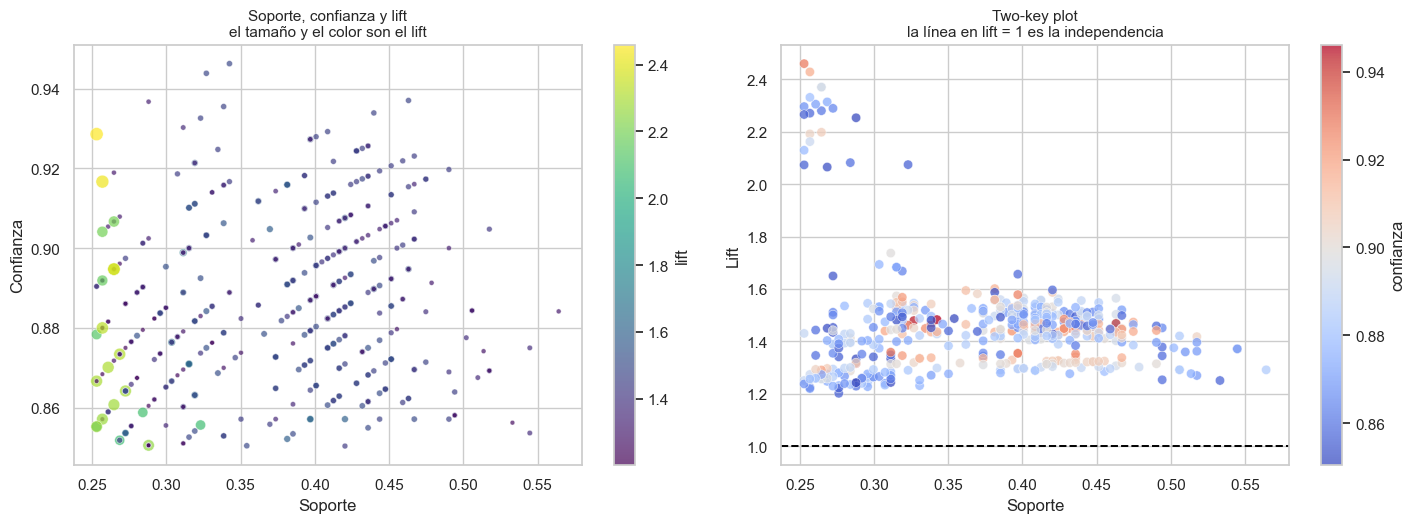

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.4))

sc = axes[0].scatter(reglas["support"], reglas["confidence"], c=reglas["lift"],
                     s=reglas["lift"] ** 3 * 6, cmap="viridis", alpha=0.7,
                     edgecolor="white", linewidth=0.4)
plt.colorbar(sc, ax=axes[0], label="lift")
axes[0].set_xlabel("Soporte"); axes[0].set_ylabel("Confianza")
axes[0].set_title("Soporte, confianza y lift\nel tamaño y el color son el lift", fontsize=11)

sc2 = axes[1].scatter(reglas["support"], reglas["lift"], c=reglas["confidence"],
                      s=45, cmap="coolwarm", alpha=0.75, edgecolor="white", linewidth=0.4)
plt.colorbar(sc2, ax=axes[1], label="confianza")
axes[1].axhline(1, color="black", ls="--", lw=1.4)
axes[1].set_xlabel("Soporte"); axes[1].set_ylabel("Lift")
axes[1].set_title("Two-key plot\nla línea en lift = 1 es la independencia", fontsize=11)

plt.tight_layout()
plt.show()

El *two-key plot* muestra la tensión estructural del método: **las reglas de mayor lift están
concentradas a la izquierda**, en la zona de soporte bajo. Las asociaciones más intensas son las
que involucran a menos casos. Es una regularidad general, no una particularidad de estos datos, y
es la razón por la que hace falta mirar las dos métricas juntas.

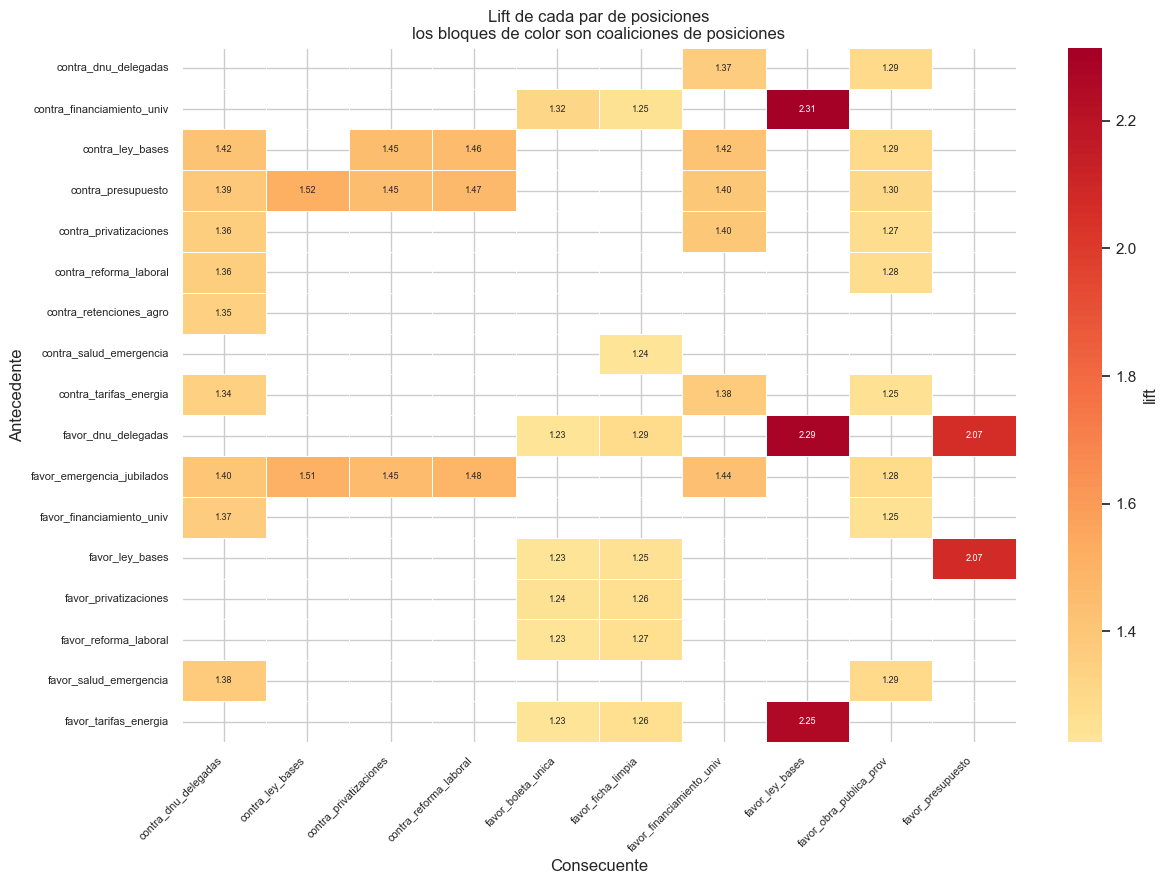

In [22]:
# Matriz antecedente × consecuente, con las reglas de un solo antecedente
simples = reglas[reglas["n_antecedentes"] == 1].copy()
simples["ant"] = simples["antecedents"].apply(lambda s: list(s)[0])

matriz = simples.pivot_table(index="ant", columns="consecuente", values="lift")

fig, ax = plt.subplots(figsize=(12.5, 9))
sns.heatmap(matriz, cmap="RdYlBu_r", center=1, annot=True, fmt=".2f",
            annot_kws={"size": 6.5}, linewidths=0.4,
            cbar_kws={"label": "lift"}, ax=ax)
ax.set_xlabel("Consecuente"); ax.set_ylabel("Antecedente")
ax.set_title("Lift de cada par de posiciones\n"
             "los bloques de color son coaliciones de posiciones", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

El heatmap ya insinúa la respuesta del notebook: hay **dos bloques de color** en la diagonal, dos
conjuntos de posiciones que se asocian entre sí y se asocian negativamente con el otro conjunto.
Falta hacerlo explícito.

In [23]:
# El grafo de reglas
G = nx.Graph()
for r in simples.itertuples():
    a, c = r.ant, r.consecuente
    if G.has_edge(a, c):
        G[a][c]["weight"] = max(G[a][c]["weight"], r.lift)
    else:
        G.add_edge(a, c, weight=r.lift)

print(f"grafo de reglas: {G.number_of_nodes()} nodos (posiciones), "
      f"{G.number_of_edges()} aristas (reglas)")

comunidades = sorted(nx.community.greedy_modularity_communities(G, weight="weight"),
                     key=len, reverse=True)
print(f"comunidades detectadas: {len(comunidades)}")
for i, com in enumerate(comunidades, 1):
    print(f"\n  AGENDA {i} ({len(com)} posiciones):")
    for p in sorted(com):
        print(f"      {p}")

grafo de reglas: 21 nodos (posiciones), 49 aristas (reglas)
comunidades detectadas: 2

  AGENDA 1 (11 posiciones):
      contra_dnu_delegadas
      contra_ley_bases
      contra_presupuesto
      contra_privatizaciones
      contra_reforma_laboral
      contra_retenciones_agro
      contra_tarifas_energia
      favor_emergencia_jubilados
      favor_financiamiento_univ
      favor_obra_publica_prov
      favor_salud_emergencia

  AGENDA 2 (10 posiciones):
      contra_financiamiento_univ
      contra_salud_emergencia
      favor_boleta_unica
      favor_dnu_delegadas
      favor_ficha_limpia
      favor_ley_bases
      favor_presupuesto
      favor_privatizaciones
      favor_reforma_laboral
      favor_tarifas_energia


C:\Users\mmill\anaconda3\envs\PYR\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10008 (\N{HEAVY BALLOT X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\mmill\anaconda3\envs\PYR\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10004 (\N{HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


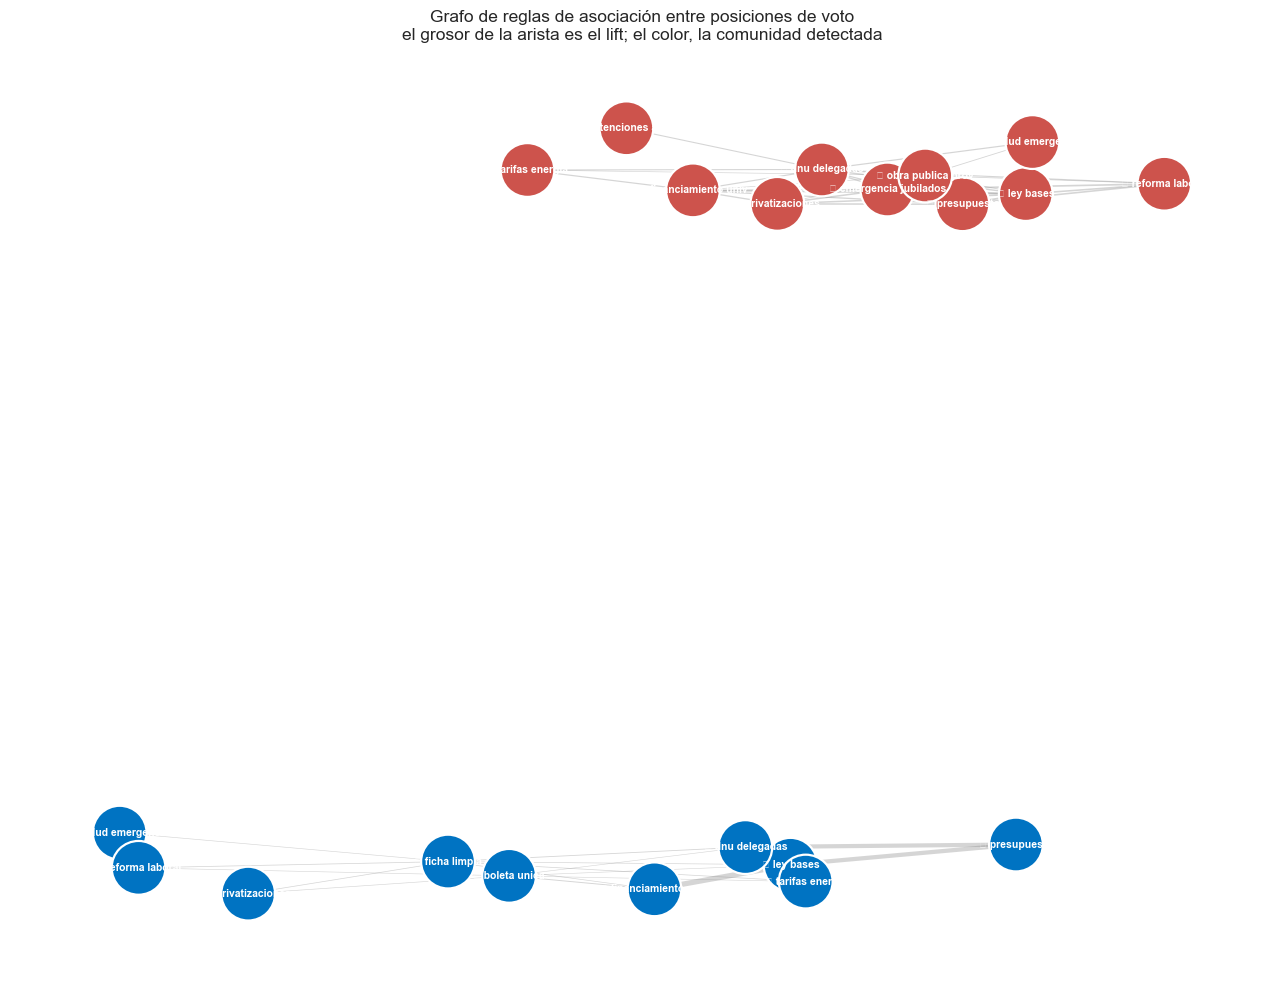

In [24]:
fig, ax = plt.subplots(figsize=(13, 10))
posiciones_grafo = nx.spring_layout(G, weight="weight", seed=SEMILLA, k=0.75, iterations=250)

color_com = {}
for i, com in enumerate(comunidades):
    for nodo in com:
        color_com[nodo] = [PALETA[2], PALETA[0], PALETA[1], PALETA[3]][i % 4]

pesos = np.array([G[u][v]["weight"] for u, v in G.edges()])
nx.draw_networkx_edges(G, posiciones_grafo, ax=ax, alpha=0.35,
                       width=(pesos - pesos.min()) / (pesos.max() - pesos.min()) * 3.4 + 0.4,
                       edge_color="#888")
nx.draw_networkx_nodes(G, posiciones_grafo, ax=ax, node_size=1500,
                       node_color=[color_com[n] for n in G.nodes()],
                       edgecolors="white", linewidths=1.6)
etiquetas = {n: n.replace("favor_", "✔ ").replace("contra_", "✘ ").replace("_", " ")
             for n in G.nodes()}
nx.draw_networkx_labels(G, posiciones_grafo, etiquetas, ax=ax, font_size=7.5,
                        font_color="white", font_weight="bold")
ax.set_title("Grafo de reglas de asociación entre posiciones de voto\n"
             "el grosor de la arista es el lift; el color, la comunidad detectada",
             fontsize=12.5)
ax.axis("off")
plt.tight_layout()
plt.show()

El grafo hace visible de un golpe lo que 473 reglas no dejaban ver: **el espacio de posiciones se
parte en dos comunidades densamente conectadas hacia adentro y poco conectadas entre sí**.

Y las dos son sustantivamente coherentes. Una reúne el rechazo a la ley de bases, el presupuesto,
las privatizaciones, la reforma laboral y las tarifas, junto con el apoyo a la emergencia
jubilatoria, el financiamiento universitario, la salud y la obra pública provincial. La otra es
exactamente su espejo.

Eso no lo sabía el algoritmo. Nunca vio la variable `bloque`.

## Cierre aplicado

Tres productos, de lo descriptivo a lo operativo.

### Producto 1: el mapa de bloques de facto

Las dos comunidades del grafo son **agendas**: conjuntos de posiciones que van juntas. La
pregunta política es cómo se relacionan con los bloques formales.

Para responderla medimos, para cada diputado, qué proporción de cada agenda cumple. Un diputado
que vota exactamente las once posiciones de la agenda 1 tiene adhesión 1.0 a esa agenda.

In [25]:
perfiles = (votaciones.pivot_table(index=["diputado", "bloque"], columns="proyecto",
                                   values="voto", aggfunc="first").reset_index())
NOMBRES_PROYECTO = [p[0] for p in PROYECTOS]

adhesion = []
for d in perfiles.itertuples():
    perfil = {f"{getattr(d, p)}_{p}" for p in NOMBRES_PROYECTO
              if getattr(d, p) != "ausente"}
    fila = {"diputado": d.diputado, "bloque": d.bloque}
    for i, com in enumerate(comunidades, 1):
        fila[f"agenda_{i}"] = len(perfil & set(com)) / len(com)
    adhesion.append(fila)

adhesion = pd.DataFrame(adhesion)
cols_agenda = [c for c in adhesion.columns if c.startswith("agenda_")]
adhesion["agenda_dominante"] = adhesion[cols_agenda].idxmax(axis=1)
# ambigüedad: 1 cuando las adhesiones a las dos agendas son iguales, 0 cuando una domina
adhesion["ambiguedad"] = (1 - (adhesion[cols_agenda].max(axis=1)
                               - adhesion[cols_agenda].min(axis=1))
                          / adhesion[cols_agenda].sum(axis=1))

mapa_facto = pd.crosstab(adhesion["bloque"], adhesion["agenda_dominante"])
mapa_facto["% en agenda_1"] = (mapa_facto["agenda_1"] /
                               mapa_facto.sum(axis=1) * 100).round(1)
mapa_facto.sort_values("% en agenda_1", ascending=False)

agenda_dominante,agenda_1,agenda_2,% en agenda_1
bloque,,,
Izquierda,5,0,100.0
Unión por la Patria,99,0,100.0
Provinciales,18,3,85.7
Coalición Federal,17,6,73.9
UCR,18,16,52.9
PRO,1,36,2.7
La Libertad Avanza,0,38,0.0


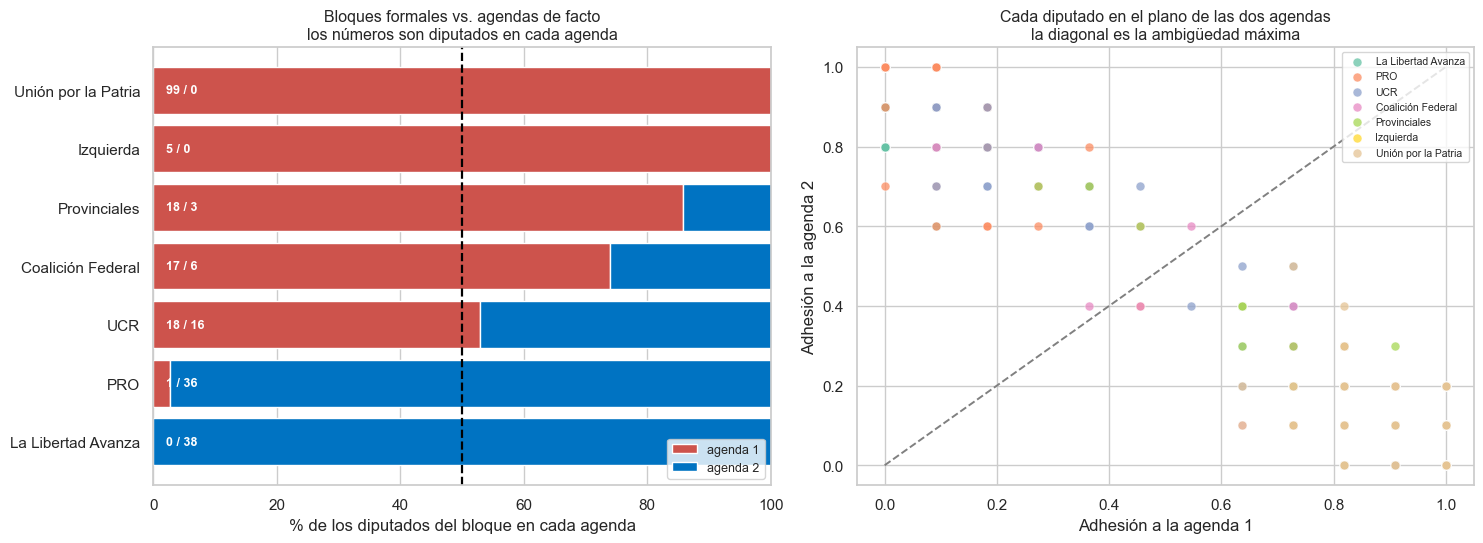

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.6))

orden_b = mapa_facto.sort_values("% en agenda_1").index
izq = mapa_facto.loc[orden_b, "agenda_1"]
der = mapa_facto.loc[orden_b, "agenda_2"]
total = izq + der
axes[0].barh(orden_b, izq / total * 100, color=PALETA[2], label="agenda 1")
axes[0].barh(orden_b, der / total * 100, left=izq / total * 100, color=PALETA[0],
             label="agenda 2")
axes[0].axvline(50, color="black", ls="--", lw=1.6)
for i, b in enumerate(orden_b):
    axes[0].text(2, i, f"{int(izq[b])} / {int(der[b])}", va="center", fontsize=9,
                 color="white", fontweight="bold")
axes[0].set_xlabel("% de los diputados del bloque en cada agenda")
axes[0].set_title("Bloques formales vs. agendas de facto\n"
                  "los números son diputados en cada agenda", fontsize=11.5)
axes[0].legend(fontsize=9, loc="lower right")

for bloque, color in zip(orden_b, sns.color_palette("Set2", len(orden_b))):
    sub = adhesion[adhesion["bloque"] == bloque]
    axes[1].scatter(sub["agenda_1"], sub["agenda_2"], s=42, alpha=0.75,
                    color=color, label=bloque, edgecolor="white", linewidth=0.5)
lims = [0, 1]
axes[1].plot(lims, lims, ls="--", color="gray", lw=1.4)
axes[1].set_xlabel("Adhesión a la agenda 1"); axes[1].set_ylabel("Adhesión a la agenda 2")
axes[1].set_title("Cada diputado en el plano de las dos agendas\n"
                  "la diagonal es la ambigüedad máxima", fontsize=11.5)
axes[1].legend(fontsize=7.5, loc="upper right")

plt.tight_layout()
plt.show()

Este es el hallazgo principal del análisis, y es una discrepancia:

**La Cámara tiene siete bloques formales y dos coaliciones de facto.** Cinco de los siete bloques
son internamente homogéneos: Unión por la Patria e Izquierda están enteramente en la agenda 1; La
Libertad Avanza y el PRO, casi enteramente en la agenda 2.

**Y la UCR se parte al medio.** Es el único bloque cuyos diputados se reparten entre las dos
agendas en proporciones comparables. No es casualidad —es el bloque al que la simulación le
asignó la disciplina más baja— pero el punto metodológico se sostiene: **el análisis de reglas
detectó la línea de fractura sin que nadie le dijera dónde buscarla ni que existieran bloques.**

En el panel derecho eso se ve como una nube dispersa a lo largo de la diagonal, mientras los
demás bloques forman grupos compactos en las esquinas.

Para quien tiene que armar una mayoría, este mapa dice algo que la lista de bloques no dice:
**negociar con "la UCR" no tiene sentido, porque la UCR no vota como una unidad.**

### Producto 2: los legisladores pivote

Dos tipos de diputado interesan a quien negocia una votación:

1. **Los ambiguos**: adhieren de forma parecida a las dos agendas. Su voto no está determinado
   por su posición general.
2. **Los desertores**: su agenda dominante **no** es la de la mayoría de su bloque. Votan
   sistemáticamente distinto de sus pares.

Los dos se calculan de lo que ya tenemos.

In [27]:
agenda_del_bloque = (adhesion.groupby("bloque")["agenda_dominante"]
                     .agg(lambda s: s.value_counts().idxmax()))
adhesion["agenda_de_su_bloque"] = adhesion["bloque"].map(agenda_del_bloque)
adhesion["desertor"] = adhesion["agenda_dominante"] != adhesion["agenda_de_su_bloque"]

print(f"diputados ambiguos (ambigüedad > 0.85): {int((adhesion['ambiguedad'] > 0.85).sum())}")
print(f"diputados desertores                  : {int(adhesion['desertor'].sum())}")
print("\nDesertores por bloque:")
print(adhesion[adhesion["desertor"]]["bloque"].value_counts().to_string())

diputados ambiguos (ambigüedad > 0.85): 8
diputados desertores                  : 26

Desertores por bloque:
bloque
UCR                  16
Coalición Federal     6
Provinciales          3
PRO                   1


In [28]:
pivotes = (adhesion.assign(
    prioridad=lambda t: t["ambiguedad"] + t["desertor"].astype(int) * 0.5)
    .nlargest(15, "prioridad"))

print("LISTA DE NEGOCIACIÓN: los 15 diputados cuyo voto es menos predecible\n")
pivotes[["diputado", "bloque", "agenda_1", "agenda_2", "ambiguedad",
         "desertor"]].round(3).reset_index(drop=True)

LISTA DE NEGOCIACIÓN: los 15 diputados cuyo voto es menos predecible



,diputado,bloque,agenda_1,agenda_2,ambiguedad,desertor
0,D216,Coalición Federal,0.545,0.6,0.952,True
1,D226,Coalición Federal,0.364,0.4,0.952,True
2,D167,PRO,0.455,0.4,0.936,True
3,D227,Coalición Federal,0.455,0.6,0.862,True
4,D239,Provinciales,0.455,0.6,0.862,True
5,D183,UCR,0.455,0.7,0.787,True
6,D196,UCR,0.364,0.6,0.755,True
7,D207,UCR,0.364,0.6,0.755,True
8,D180,UCR,0.364,0.7,0.684,True
9,D238,Provinciales,0.364,0.7,0.684,True


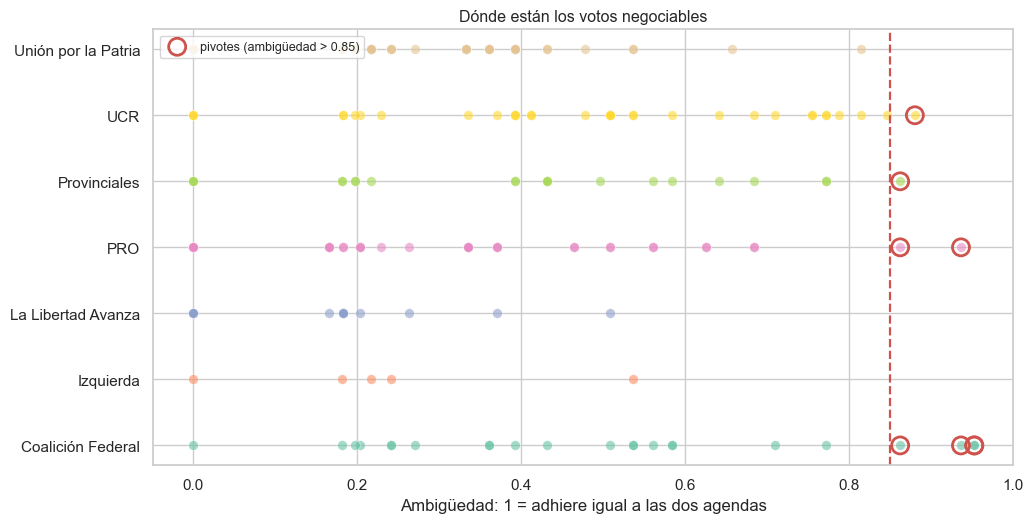

In [29]:
fig, ax = plt.subplots(figsize=(10.5, 5.4))
for bloque, color in zip(mapa_facto.index, sns.color_palette("Set2", len(mapa_facto))):
    sub = adhesion[adhesion["bloque"] == bloque]
    ax.scatter(sub["ambiguedad"], np.full(len(sub), bloque), s=48, alpha=0.6,
               color=color, edgecolor="white", linewidth=0.4)
sub_piv = adhesion[adhesion["ambiguedad"] > 0.85]
ax.scatter(sub_piv["ambiguedad"], sub_piv["bloque"], s=150, facecolor="none",
           edgecolor=PALETA[2], linewidth=2, label="pivotes (ambigüedad > 0.85)")
ax.axvline(0.85, color=PALETA[2], ls="--", lw=1.6)
ax.set_xlabel("Ambigüedad: 1 = adhiere igual a las dos agendas")
ax.set_title("Dónde están los votos negociables", fontsize=11.5)
ax.legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()

Los pivotes **no están distribuidos al azar**: se concentran en Coalición Federal, UCR, PRO y
Provinciales, y no aparecen en Unión por la Patria, La Libertad Avanza ni Izquierda.

Para una estrategia legislativa eso es directamente operativo: la lista nombra a quién conviene
dedicarle tiempo, y dice que buscar votos en los bloques disciplinados es esfuerzo perdido.

### Producto 3: predecir el voto en un proyecto nuevo

La prueba más exigente. Tres decisiones de diseño para que la evaluación sea honesta:

1. Se **ocultan tres proyectos**: las reglas solo pueden usar posiciones sobre los otros doce
   como antecedente.
2. Se **parte la Cámara en dos**: las reglas se extraen del 70% de los diputados y se evalúan
   sobre el 30% restante, que el algoritmo no vio. Sin esa partición estaríamos midiendo sobre
   los mismos datos que produjeron las reglas.
3. El **baseline se calcula también solo con el conjunto de entrenamiento**: la mayoría de cada
   bloque se estima con los diputados de entrenamiento.

Es el mismo principio de `9.0` aplicado a un método no supervisado. Si las reglas no le ganan a
"mirá de qué partido es", no aportan capacidad predictiva.

In [30]:
OCULTOS = ["ley_bases", "coparticipacion", "financiamiento_univ"]
VISIBLES = [p for p in NOMBRES_PROYECTO if p not in OCULTOS]

# partición por diputado: las reglas no ven a los del conjunto de evaluación
rng_split = np.random.default_rng(SEMILLA)
todos = canasta.index.to_numpy()
rng_split.shuffle(todos)
corte = int(0.70 * len(todos))
dip_train, dip_test = set(todos[:corte]), set(todos[corte:])
print(f"diputados para extraer reglas: {len(dip_train)}")
print(f"diputados para evaluar       : {len(dip_test)}")

canasta_train = canasta.loc[sorted(dip_train)]

frec_pred = apriori(canasta_train, min_support=0.20, use_colnames=True, max_len=3)
reglas_pred = association_rules(frec_pred, num_itemsets=len(canasta_train),
                                metric="confidence", min_threshold=0.80)
reglas_pred = reglas_pred[reglas_pred["consequents"].apply(len) == 1].copy()
reglas_pred["ant"] = reglas_pred["antecedents"].apply(frozenset)
reglas_pred["con"] = reglas_pred["consequents"].apply(lambda s: list(s)[0])

# el consecuente debe ser un proyecto oculto y el antecedente NO puede usarlos
def usa_oculto(items):
    return any(x.rsplit("favor_", 1)[-1].rsplit("contra_", 1)[-1] in OCULTOS for x in items)

reglas_pred = reglas_pred[
    reglas_pred["con"].apply(lambda c: any(c.endswith("_" + o) for o in OCULTOS))
    & ~reglas_pred["ant"].apply(usa_oculto)]
print(f"\nreglas utilizables (consecuente oculto, antecedente visible): {len(reglas_pred)}")

# baseline: la mayoría de cada bloque, estimada SOLO con el conjunto de entrenamiento
mayoria_bloque = (emitidos[emitidos["diputado"].isin(dip_train)]
                  .groupby(["bloque", "proyecto"])["voto"]
                  .agg(lambda s: s.value_counts().idxmax()))

diputados para extraer reglas: 179
diputados para evaluar       : 78

reglas utilizables (consecuente oculto, antecedente visible): 200


In [31]:
def predecir_con_reglas(perfil_visible, proyecto):
    '''Voto ponderado de todas las reglas aplicables. Devuelve None si no hay ninguna.'''
    aplican = reglas_pred[
        reglas_pred["con"].str.endswith("_" + proyecto)
        & reglas_pred["ant"].apply(lambda a: a <= perfil_visible)]
    if aplican.empty:
        return None
    puntaje = (aplican.assign(peso=aplican["confidence"] * np.log(aplican["lift"].clip(lower=1e-9)))
               .groupby("con")["peso"].sum())
    return puntaje.idxmax().rsplit("_" + proyecto, 1)[0]


registros_eval = []
for d in perfiles.itertuples():
    if d.diputado not in dip_test:          # solo se evalúa sobre diputados no vistos
        continue
    perfil = frozenset(f"{getattr(d, p)}_{p}" for p in VISIBLES
                       if getattr(d, p) != "ausente")
    for oculto in OCULTOS:
        real = getattr(d, oculto)
        if real == "ausente":
            continue
        base = mayoria_bloque.loc[(d.bloque, oculto)]
        regla = predecir_con_reglas(perfil, oculto)
        registros_eval.append({
            "diputado": d.diputado, "bloque": d.bloque, "proyecto": oculto,
            "real": real, "por_bloque": base,
            "por_reglas": regla if regla is not None else base,
            "hubo_regla": regla is not None,
        })

evaluacion = pd.DataFrame(registros_eval)
print(f"casos evaluados: {len(evaluacion)}")
print(f"casos sin ninguna regla aplicable: {int((~evaluacion['hubo_regla']).sum())} "
      f"({(~evaluacion['hubo_regla']).mean():.1%})\n")

resumen = pd.DataFrame([
    {"estrategia": "BASELINE: vota como la mayoría de su bloque",
     "exactitud": (evaluacion["por_bloque"] == evaluacion["real"]).mean()},
    {"estrategia": "Reglas de asociación (voto ponderado)",
     "exactitud": (evaluacion["por_reglas"] == evaluacion["real"]).mean()},
]).round(4)
resumen

casos evaluados: 218
casos sin ninguna regla aplicable: 19 (8.7%)



,estrategia,exactitud
0,BASELINE: vota como la mayoría de su bloque,0.8578
1,Reglas de asociación (voto ponderado),0.8624


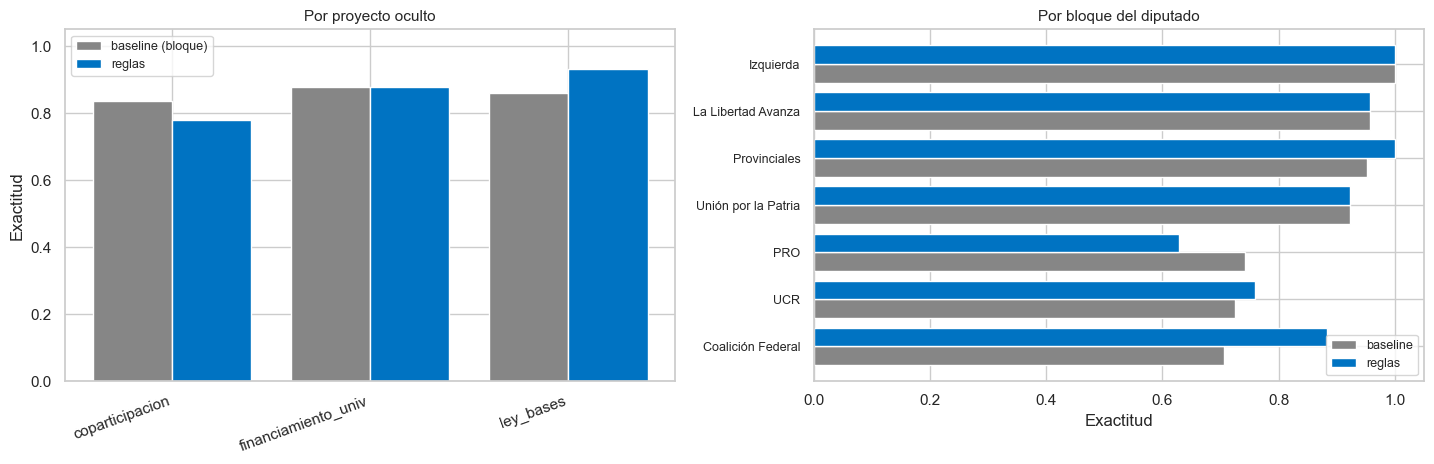

,casos,baseline,reglas,diferencia
proyecto,,,,
coparticipacion,73.0,0.836,0.781,-0.055
financiamiento_univ,73.0,0.877,0.877,0.000
ley_bases,72.0,0.861,0.931,0.069


In [32]:
# ¿Dónde gana cada estrategia?
por_proyecto = evaluacion.groupby("proyecto").apply(
    lambda g: pd.Series({
        "casos": len(g),
        "baseline": (g["por_bloque"] == g["real"]).mean(),
        "reglas": (g["por_reglas"] == g["real"]).mean(),
    }), include_groups=False)
por_proyecto["diferencia"] = (por_proyecto["reglas"] - por_proyecto["baseline"]).round(4)

fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.8))

x = np.arange(len(por_proyecto))
axes[0].bar(x - 0.2, por_proyecto["baseline"], 0.4, color=PALETA[3], label="baseline (bloque)")
axes[0].bar(x + 0.2, por_proyecto["reglas"], 0.4, color=PALETA[0], label="reglas")
axes[0].set_xticks(x); axes[0].set_xticklabels(por_proyecto.index, rotation=20, ha="right")
axes[0].set_ylabel("Exactitud"); axes[0].set_ylim(0, 1.05)
axes[0].set_title("Por proyecto oculto", fontsize=11)
axes[0].legend(fontsize=9)

por_bloque_ev = evaluacion.groupby("bloque").apply(
    lambda g: pd.Series({
        "baseline": (g["por_bloque"] == g["real"]).mean(),
        "reglas": (g["por_reglas"] == g["real"]).mean(),
    }), include_groups=False).sort_values("baseline")
xb = np.arange(len(por_bloque_ev))
axes[1].barh(xb - 0.2, por_bloque_ev["baseline"], 0.4, color=PALETA[3], label="baseline")
axes[1].barh(xb + 0.2, por_bloque_ev["reglas"], 0.4, color=PALETA[0], label="reglas")
axes[1].set_yticks(xb); axes[1].set_yticklabels(por_bloque_ev.index, fontsize=9)
axes[1].set_xlabel("Exactitud"); axes[1].set_xlim(0, 1.05)
axes[1].set_title("Por bloque del diputado", fontsize=11)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

por_proyecto.round(3)

### El resultado honesto

**Las reglas empatan con el baseline.** Alrededor de 0.86 las dos, con una diferencia de
milésimas que no significa nada.

Y eso hay que decirlo sin adornos: para **predecir** el voto de un diputado, saber de qué bloque
es alcanza. Las 200 reglas extraídas del conjunto de entrenamiento mejoran el baseline en menos
de medio punto — una diferencia que con 218 casos evaluados no se distingue del ruido.

Tres razones, y las tres son lecciones sobre el método:

1. **Las reglas están capturando la pertenencia al bloque**, no algo distinto de ella. El grafo
   de comunidades ya lo mostraba: las agendas coinciden con las coaliciones partidarias. Es el
   caso de manual de una asociación que refleja una variable latente compartida.
2. **Cobertura incompleta.** En el 8.7% de los casos no hay ninguna regla aplicable al perfil de
   ese diputado y hay que recurrir al baseline igual. Acá es un porcentaje chico porque los
   umbrales son laxos, pero crece rápido al exigir más soporte o más confianza. Un sistema basado
   en reglas siempre tiene ese problema, y es una de las razones por las que los clasificadores
   basados en reglas cedieron terreno frente a los árboles de `9.3`, que **siempre** producen una
   predicción.
3. **A priori no está diseñado para predecir.** Optimiza el descubrimiento de patrones
   frecuentes, no el error de clasificación. Si el objetivo es predecir un voto, el método
   correcto es el de `9.3`.

El panel por bloque muestra lo esperable: donde las dos estrategias tienen más dificultad es en
los bloques indisciplinados —los mismos donde están los pivotes— y ahí es donde las reglas, que
usan el patrón individual y no la etiqueta partidaria, tienen su mejor chance.

### El producto, entonces

Lo que este notebook entrega **no** es un predictor:

1. **Un mapa de coalición de facto** que muestra que la Cámara tiene siete bloques formales y dos
   agendas reales, y que identifica a la UCR como la línea de fractura — sin haber usado la
   variable de bloque en ningún momento del análisis.
2. **Una lista de 15 legisladores pivote**, con su bloque y su grado de ambigüedad, que responde
   la pregunta operativa de a quién hay que ir a buscar para conseguir una mayoría.
3. **Un resultado negativo bien establecido**: las reglas no mejoran la predicción del voto
   individual sobre la etiqueta partidaria. Saberlo evita construir un sistema que no iba a
   funcionar.

El valor de las reglas de asociación es **descriptivo y exploratorio**: hacen visible una
estructura que no estaba declarada en los datos. Para eso son muy buenas. Para predecir hay
otras herramientas, y este notebook lo muestra en lugar de afirmarlo.

## Síntesis

1. Las reglas de asociación buscan **co-ocurrencia entre atributos**, no similitud entre casos.
   La unidad de análisis es la transacción y el dato es un conjunto de ítems presentes.

2. **El soporte acota, la confianza describe, el lift decide.** Una confianza de 0.667 con lift
   de 0.95 es una regla sin contenido: el consecuente era frecuente de todas formas. Ordenar
   reglas por confianza es reportar qué ítems son frecuentes.

3. **Leverage** pondera por frecuencia y **conviction** es sensible a la dirección. Ordenar por
   lift y por leverage da listas distintas, y cuál conviene depende de si se busca entender o
   actuar.

4. La **propiedad de clausura descendente** —si un conjunto es infrecuente, ningún superconjunto
   puede ser frecuente— es lo que hace tratable un problema de $2^{30}$ candidatos.

5. **El umbral de soporte es una decisión de fondo**: bajarlo de 0.40 a 0.05 multiplica la salida
   por más de veinte, y treinta mil reglas son tan inútiles como ninguna.

6. Codificar **dos ítems por proyecto** (`favor_X` y `contra_X`) conserva la mitad de la
   información que se perdería con la codificación ingenua: las coaliciones se construyen tanto
   sobre rechazos compartidos como sobre apoyos.

7. El **grafo de reglas con detección de comunidades** es lo que hace legibles cientos de reglas:
   convierte una tabla en un mapa de dos agendas.

8. **Asociación no es causa, y en este caso la asociación refleja una variable latente**: las
   agendas descubiertas coinciden con las coaliciones partidarias. Que el método lo descubra sin
   ver la variable de bloque es su virtud; confundir eso con haber explicado el voto sería el
   error.

9. Las reglas **no mejoran la predicción** sobre el baseline partidario —0.862 contra 0.858 sobre
   diputados no vistos— y la razón es estructural: cobertura incompleta y un objetivo de
   optimización que no es el error de clasificación.

## Cierre de la unidad

Los seis notebooks recorrieron el mapa completo de `9.0`:

| Notebook | Rama | Método | Y lo que enseñó más allá del método |
|---|---|---|---|
| `9.1` | supervisado · regresión | Ridge, Lasso, Elastic Net | el $\lambda$ de la predicción no es el de la interpretación |
| `9.2` | supervisado · clasificación | logística regularizada | los faltantes estructurales no se imputan |
| `9.3` | supervisado · clasificación | árbol, RF, XGBoost | con 7.233 casos los ensambles ganan, pero por dos puntos |
| `9.3b` | supervisado · clasificación | los mismos, con 132 casos | y con el n que uno tiene de verdad, no ganan |
| `9.4` | no supervisado | jerárquico, k-means, PCA | sin etiqueta, la validación es externa |
| `9.5` | no supervisado | a priori | asociación no es causa, y describir no es predecir |

Y una regularidad que atravesó los seis: **en cada notebook, lo que más movió el resultado
fueron los datos y las decisiones sobre los datos, no la elección del método.** El leakage de
`wbgi_cce`, los faltantes estructurales de la encuesta, el `min_samples_leaf` por defecto del
bosque, la escala sin estandarizar en el clustering, el umbral de soporte acá. Los métodos son
seis; los modos de equivocarse con los datos, muchos más.